In [7]:
import pandas as pd
import numpy as np

In [8]:
df = pd.read_csv('cleaned_data.csv')

In [9]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


In [11]:
df['age_group'] = pd.cut(
    df['age'],
    bins = [0, 30, 50, 100],
    labels = ['0-30', '30-50', '50+'])

In [12]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1,50+
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1,50+
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1,50+
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1,30-50
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1,50+


In [13]:
stroke_rate = df.groupby('age_group')['stroke'].mean()

In [14]:
stroke_rate

age_group
0-30     0.001274
30-50    0.014862
50+      0.106253
Name: stroke, dtype: float64

In [17]:
group_analysis = df.groupby('age_group').agg({
    'stroke': 'mean',
    'avg_glucose_level': 'mean',
    'bmi': 'mean'})

In [18]:
group_analysis

,stroke,avg_glucose_level,bmi
age_group,,,
0-30,0.001274,94.258758,24.506096
30-50,0.014862,100.022357,31.244351
50+,0.106253,118.992379,30.569630


In [19]:
import matplotlib.pyplot as plt

In [20]:
import seaborn as sns

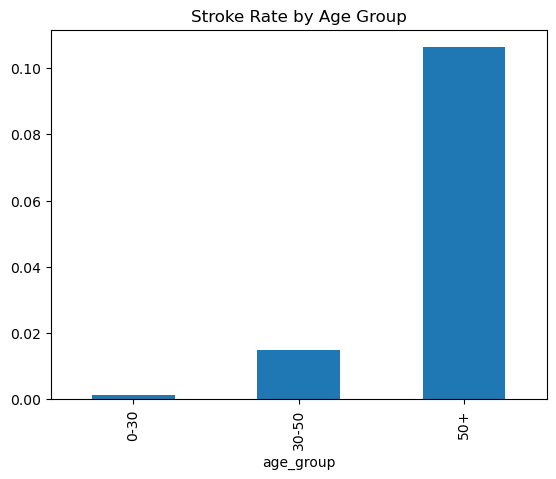

In [21]:
group_analysis['stroke'].plot(kind='bar')
plt.title ('Stroke Rate by Age Group')
plt.show()

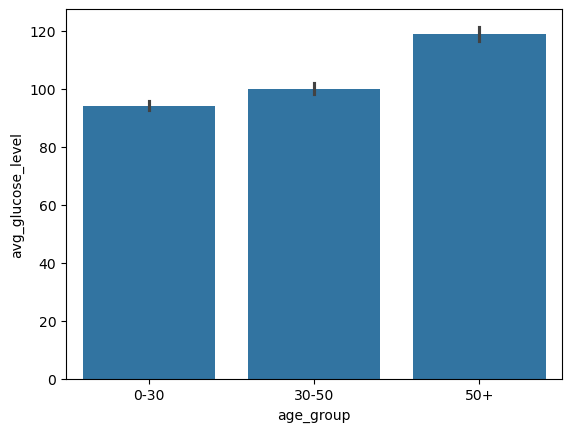

In [22]:
sns.barplot(x='age_group', y='avg_glucose_level', data=df)
plt.show()

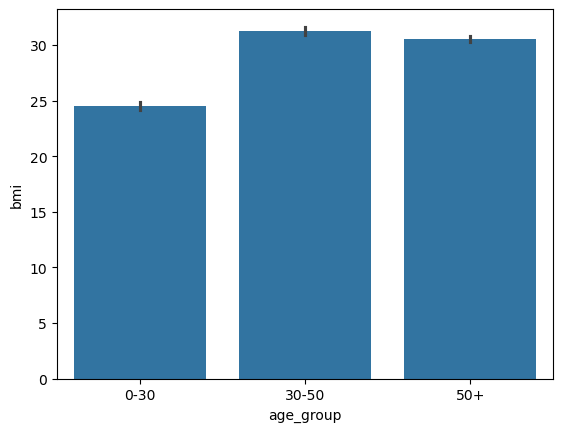

In [23]:
sns.barplot(x='age_group', y='bmi', data=df)
plt.show()

### Key Findings

1. Stroke rate increases significantly with age.
2. The 50+ group has the highest risk.

### Insight

- Age is the strongest risk factor for stroke.

### Recommendation

- Focus preventive efforts on the 50+ population.

### Key Findings

1. Stroke rate increases significantly with age.
2. The 50+ group has the highest risk.

### Insight

- Age is the strongest risk factor for stroke.

### Recommendation

- Focus preventive efforts on the 50+ population.

In [27]:
df['glucose_group'] = pd.qcut(
    df['avg_glucose_level'],
    q=3,
    labels=['low', 'medium', 'high']
)